In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import shap
import pickle
import warnings
warnings.filterwarnings('ignore')

# Install shap if not already installed
import subprocess
subprocess.run(['pip', 'install', 'shap'], capture_output=True)
import shap

print("Libraries imported successfully")

Libraries imported successfully


In [3]:
# Load Data and Model
df = pd.read_csv('../data/processed/city_daily_clean.csv')
df['date'] = pd.to_datetime(df['date'])

# Encode season and city
from sklearn.preprocessing import LabelEncoder
le_season = LabelEncoder()
le_city = LabelEncoder()
df['season_enc'] = le_season.fit_transform(df['season'])
df['city_enc'] = le_city.fit_transform(df['city'])

# Load saved XGBoost model
xgb_model = xgb.XGBRegressor()
xgb_model.load_model('../src/models/xgboost_source.json')

print("Data and model loaded successfully")
print("Shape:", df.shape)

Data and model loaded successfully
Shape: (19018, 19)


In [4]:
# Prepare Features
feature_cols = [
    'PM10', 'NO', 'NO2', 'NOx', 'NH3',
    'SO2', 'CO', 'Ozone', 'Benzene',
    'month', 'day_of_week', 'season_enc', 'city_enc'
]

target = 'PM25'

df_model = df[feature_cols + [target]].dropna()
X = df_model[feature_cols]
y = df_model[target]

print("Features shape:", X.shape)

Features shape: (15246, 13)


In [6]:
# compute SHAP values
print("Computing SHAP values")

# Use TreeExplainer for XGBoost
explainer = shap.TreeExplainer(xgb_model)

# Use sample of 2000 rows for speed
sample = X.sample(2000, random_state=42)
shap_values = explainer.shap_values(sample)

print("SHAP values computed successfully")
print("SHAP values shape:", shap_values.shape)

Computing SHAP values
SHAP values computed successfully
SHAP values shape: (2000, 13)


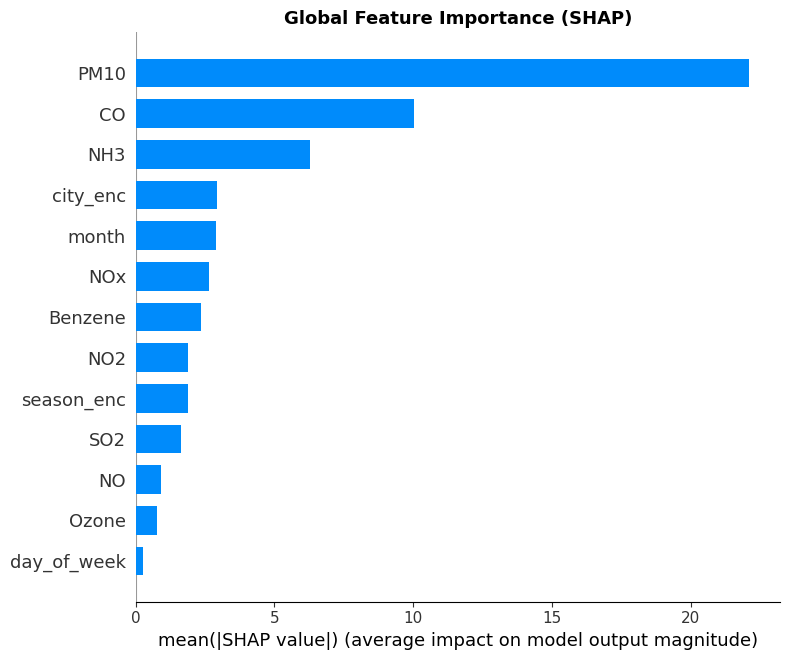

Global SHAP importance plot saved


In [7]:
# Global feature importance 
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values,
    sample,
    feature_names=feature_cols,
    plot_type='bar',
    show=False
)
plt.title('Global Feature Importance (SHAP)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/shap_global_importance.png', dpi=150)
plt.show()
print("Global SHAP importance plot saved")

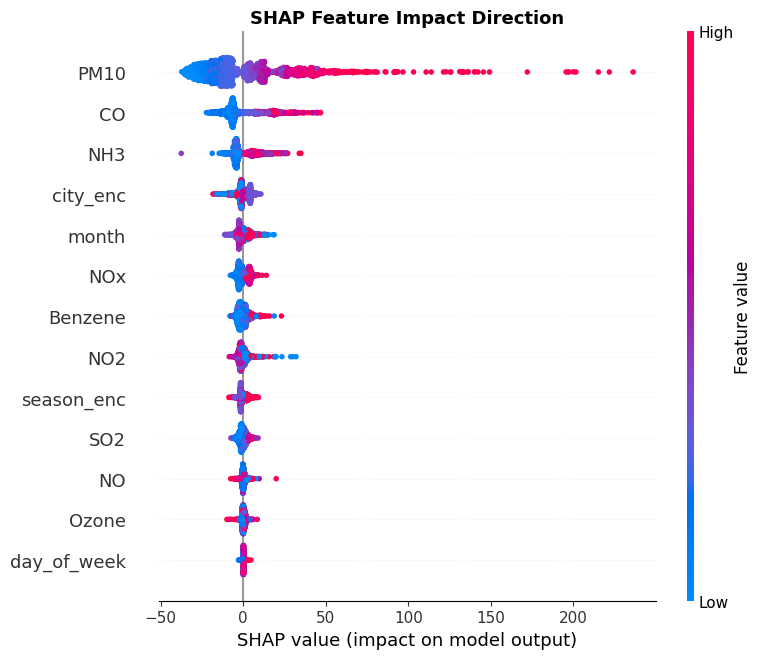

Beeswarm plot saved


In [8]:
# SHAP beeswarm plot (shows direction of impact)
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values,
    sample,
    feature_names=feature_cols,
    show=False
)
plt.title('SHAP Feature Impact Direction', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/shap_beeswarm.png', dpi=150)
plt.show()
print("Beeswarm plot saved")

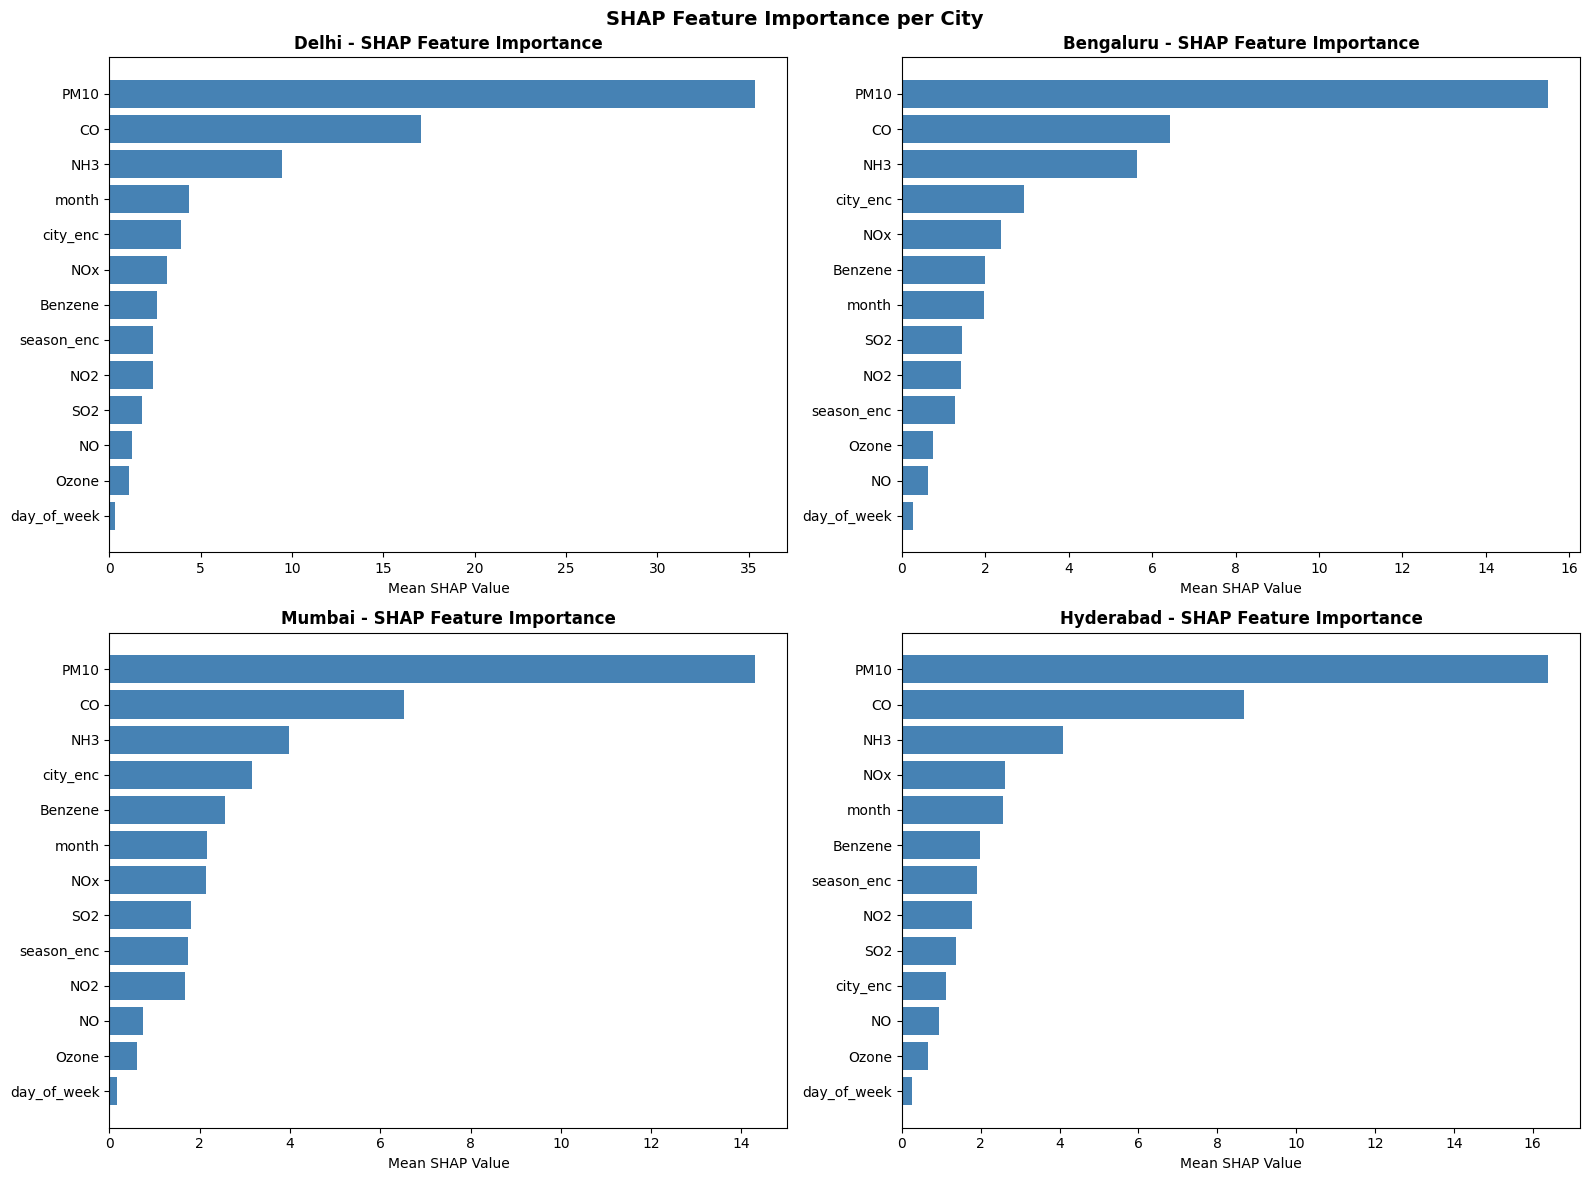

In [9]:
# SHAP per city
cities = ['Delhi', 'Bengaluru', 'Mumbai', 'Hyderabad']
city_shap = {}

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for ax, city in zip(axes.flatten(), cities):
    city_df = df[df['city'] == city][feature_cols + [target]].dropna()
    X_city = city_df[feature_cols]

    # Sample max 500 rows per city
    if len(X_city) > 500:
        X_city = X_city.sample(500, random_state=42)

    shap_city = explainer.shap_values(X_city)
    city_shap[city] = shap_city

    # Mean absolute SHAP per feature
    mean_shap = np.abs(shap_city).mean(axis=0)
    importance = pd.Series(mean_shap, index=feature_cols).sort_values(ascending=True)

    ax.barh(importance.index, importance.values, color='steelblue')
    ax.set_title(f'{city} - SHAP Feature Importance', fontweight='bold')
    ax.set_xlabel('Mean SHAP Value')

plt.suptitle('SHAP Feature Importance per City', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/processed/shap_per_city.png', dpi=150)
plt.show()

Confidence Analysis per City
---------------------------------------------
Delhi        - Confidence Score: 0.5463 (54.6%)
Bengaluru    - Confidence Score: 0.7376 (73.8%)
Mumbai       - Confidence Score: 0.8029 (80.3%)
Hyderabad    - Confidence Score: 0.6938 (69.4%)


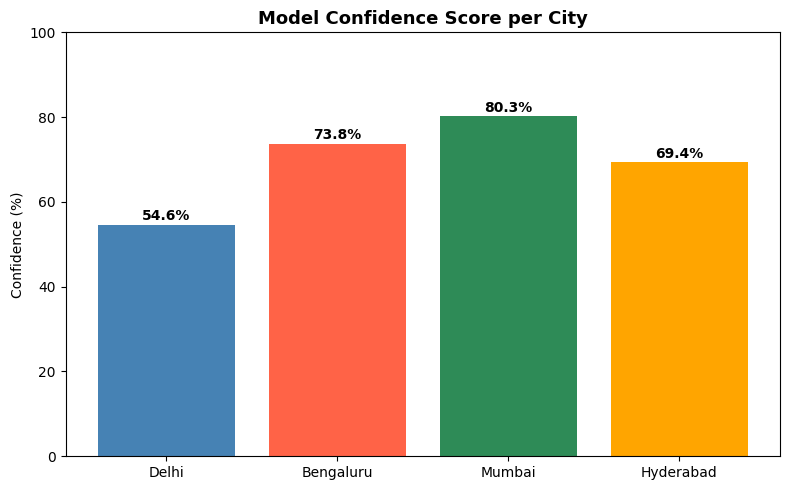

In [10]:
# Confidence score per prediction
# Confidence score = how consistent SHAP values are
# Low variance in SHAP = high confidence

print("Confidence Analysis per City")
print("-" * 45)

confidence_results = {}

for city in cities:
    city_df = df[df['city'] == city][feature_cols + [target]].dropna()
    X_city = city_df[feature_cols]

    if len(X_city) > 500:
        X_city = X_city.sample(500, random_state=42)

    shap_city = explainer.shap_values(X_city)

    # Confidence = 1 - normalized std of total shap per sample
    total_shap = np.abs(shap_city).sum(axis=1)
    confidence = 1 - (total_shap.std() / total_shap.mean())
    confidence = max(0, min(1, confidence))

    confidence_results[city] = confidence
    print(f"{city:12} - Confidence Score: {confidence:.4f} ({confidence*100:.1f}%)")

# Plot confidence scores
plt.figure(figsize=(8, 5))
city_names = list(confidence_results.keys())
scores = [confidence_results[c] * 100 for c in city_names]
colors = ['steelblue', 'tomato', 'seagreen', 'orange']
plt.bar(city_names, scores, color=colors)
plt.title('Model Confidence Score per City', fontsize=13, fontweight='bold')
plt.ylabel('Confidence (%)')
plt.ylim(0, 100)
for i, v in enumerate(scores):
    plt.text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

In [12]:
# Save SHAP results
import os
os.makedirs('../src/models', exist_ok=True)

with open('../src/models/shap_explainer.pkl', 'wb') as f:
    pickle.dump(explainer, f)
print("SHAP explainer saved")

with open('../src/models/confidence_results.pkl', 'wb') as f:
    pickle.dump(confidence_results, f)
print("Confidence results saved")

print("\nExplainable AI Summary:")

for city in cities:
    print(f"{city:12} - Confidence: {confidence_results[city]*100:.1f}%")

print("\nTop 3 Pollution Sources (Global):")
global_importance = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=feature_cols
).sort_values(ascending=False)

for i, (feature, score) in enumerate(global_importance.head(3).items()):
    print(f"  {i+1}. {feature} - SHAP: {score:.4f}")

SHAP explainer saved
Confidence results saved

Explainable AI Summary:
Delhi        - Confidence: 54.6%
Bengaluru    - Confidence: 73.8%
Mumbai       - Confidence: 80.3%
Hyderabad    - Confidence: 69.4%

Top 3 Pollution Sources (Global):
  1. PM10 - SHAP: 22.1100
  2. CO - SHAP: 10.0449
  3. NH3 - SHAP: 6.2826
